**Machine Learning Final Project**

---

[ Members ]
*   5025241012 | Dewey Sutjiadi
*   5025241079 | Isabel Hayaaulia Ismail
*   5025241082 | Ardian Saptaguna Yudistira
*   5025241166 | Krisna Widhi Wijaya

[ Dataset Link ]

https://www.kaggle.com/datasets/mexwell/heart-disease-dataset/data?select=heart_statlog_cleveland_hungary_final.csv

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mexwell/heart-disease-dataset")
path = path + "/heart_statlog_cleveland_hungary_final.csv"
print("Path to dataset files:", path)

100%|██████████| 399k/399k [00:00<00:00, 28.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/heart-disease-dataset/versions/2/heart_statlog_cleveland_hungary_final.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

print("Success")

Success


**Feature Description**

---

Sex :

0 = Female, 1 = Male

---

Chest Pain Type :

1 = Typical angina

2 = Atypical angina

3 = Non-anginal pain

4 = Asymptomatic

---

Fasting Blood Sugar :

0 = Fasting blood sugar <= 120mg/dl

1 = Fasting blood sugar > 120mg/dl

---

Resting ECG :

0 = Normal

1 = Has ST-T wave abnormality

2 = Shows probable/definite left ventricular hypertrophy

---

Exercise Angina :

0 = No

1 = Yes

---

ST Slope :

1 = Upsloping

2 = Flat

3 = Downsloping

---

Class :

0 = Normal

1 = Heart Disease

In [ ]:
df = pd.read_csv(path)
print(f'Current dataframe : {df.shape}')

df.head(5)

Current dataframe : (1190, 12)


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [ ]:
missing_data = df.isnull().sum()
print(missing_data)

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64


In [ ]:
columns = df.columns
for i, col in enumerate (columns):
  print(f"Columns {i} = ", df[col].nunique())

Columns 0 =  50
Columns 1 =  2
Columns 2 =  4
Columns 3 =  67
Columns 4 =  222
Columns 5 =  2
Columns 6 =  3
Columns 7 =  119
Columns 8 =  2
Columns 9 =  53
Columns 10 =  4
Columns 11 =  2


In [ ]:
columns_with_little_unique_values = []
columns_with_many_unique_values = []
for i in columns:
  if (df[i].nunique() < 10):
    columns_with_little_unique_values.append(i)
  else:
    columns_with_many_unique_values.append(i)

print(len(columns_with_little_unique_values), "columns with less than 10 unique values :\n", columns_with_little_unique_values)
print(len(columns_with_many_unique_values), "columns with more than or equal to 10 unique values :\n", columns_with_many_unique_values)

7 columns with less than 10 unique values :
 ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope', 'target']
5 columns with more than or equal to 10 unique values :
 ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']


In [ ]:
sex_mapping = {
    0: "F",
    1: "M"
}

chest_pain_mapping = {
    1: "TA",
    2: "AA",
    3: "NAP",
    4: "ASYM"
}

fasting_blood_sugar_mapping = {
    0: "<=120mg/dl",
    1: ">120mg/dl"
}

resting_ecg_mapping = {
    0: "Normal",
    1: "Wave Abnormal",
    2: "L.V. Hypertrophy"
}

exercise_angina_mapping = {
    0: "No",
    1: "Yes"
}

st_slope_mapping = {
    1: "Upsloping",
    2: "Flat",
    3: "Downsloping"
}

target_mapping = {
    0: "Normal",
    1: "Heart Disease"
}

label_mapping = {
    'sex': sex_mapping,
    'chest pain type': chest_pain_mapping,
    'fasting blood sugar': fasting_blood_sugar_mapping,
    'resting ecg': resting_ecg_mapping,
    'exercise angina': exercise_angina_mapping,
    'ST slope': st_slope_mapping,
    'target': target_mapping
}

In [ ]:
df_plot = df.copy()
df_plot['sex'] = df_plot['sex'].map(sex_mapping)
df_plot['chest pain type'] = df_plot['chest pain type'].map(chest_pain_mapping)
df_plot['fasting blood sugar'] = df_plot['fasting blood sugar'].map(fasting_blood_sugar_mapping)
df_plot['resting ecg'] = df_plot['resting ecg'].map(resting_ecg_mapping)
df_plot['exercise angina'] = df_plot['exercise angina'].map(exercise_angina_mapping)
df_plot['ST slope'] = df_plot['ST slope'].map(st_slope_mapping)
df_plot['target'] = df_plot['target'].map(target_mapping)

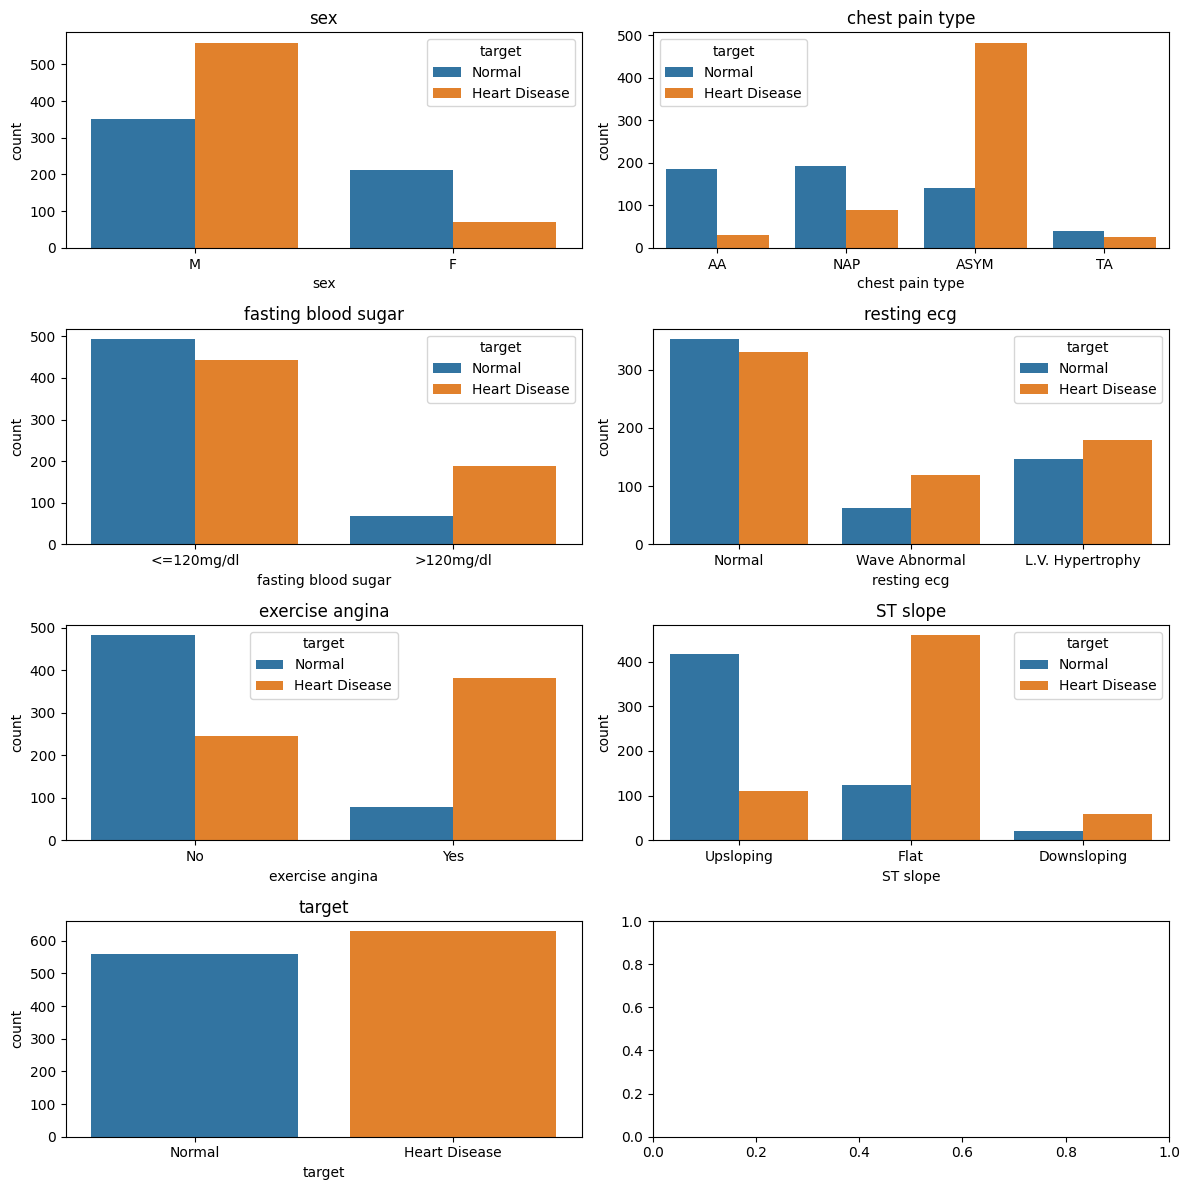

In [ ]:
# https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/

fig_bar, axes = plt.subplots(4,2, figsize=(12,12))
axes = axes.flatten() # returns the array in 1D

for i, feature in enumerate(columns_with_little_unique_values):
  sns.countplot(data=df_plot, x=feature, hue='target', ax=axes[i])
  axes[i].set_title(feature)

plt.tight_layout()
plt.show()

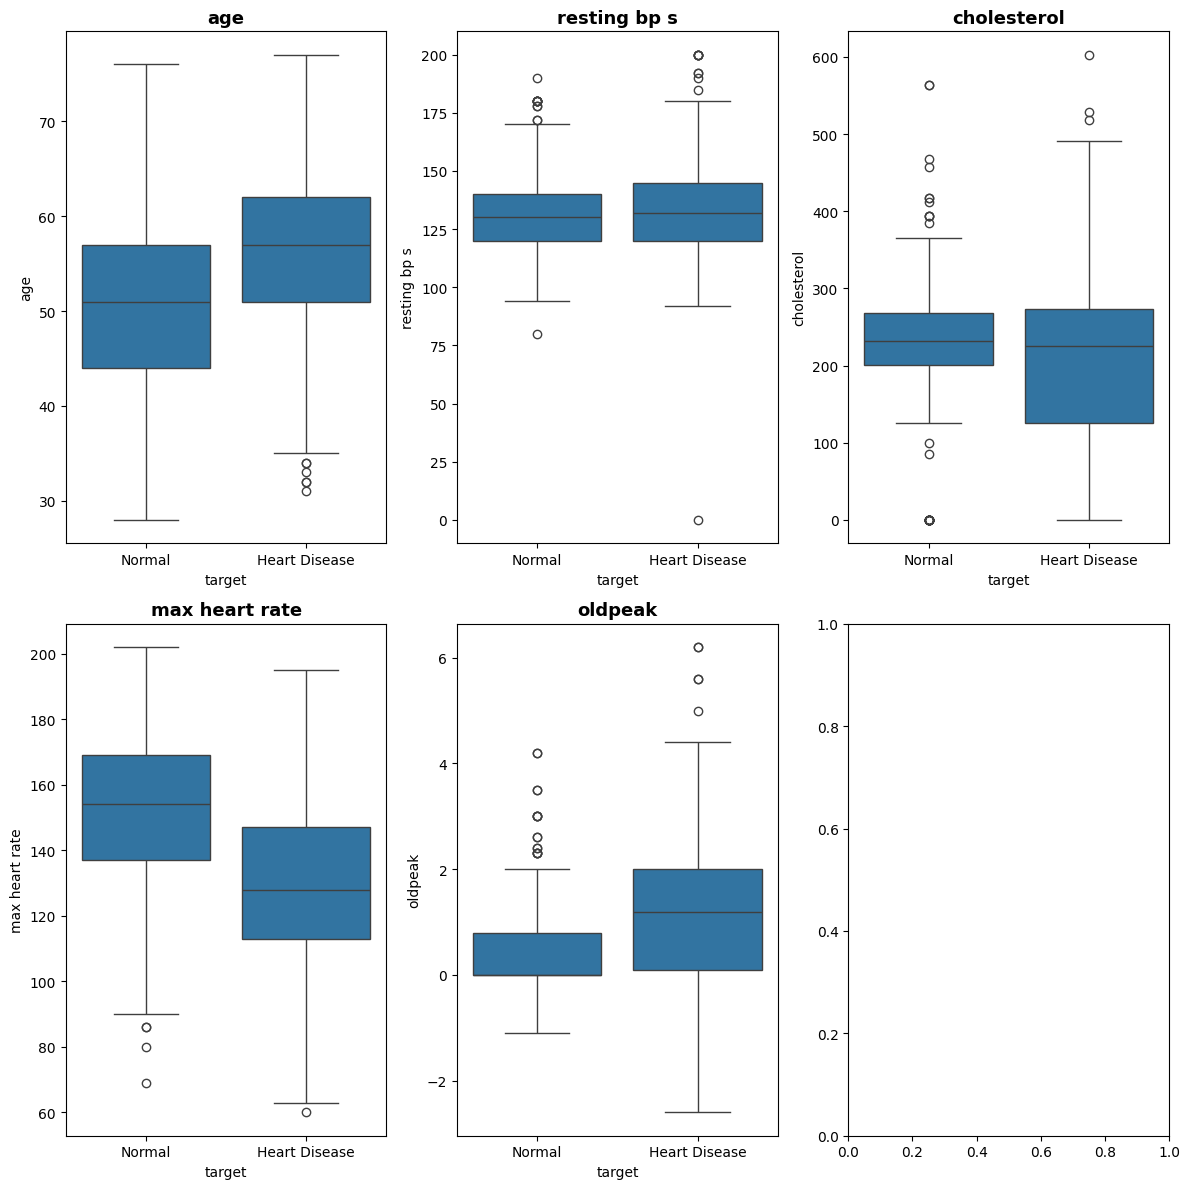

In [ ]:
fig_box, axes = plt.subplots(2,3, figsize=(12,12))
axes = axes.flatten()

for i, feature in enumerate(columns_with_many_unique_values):

  sns.boxplot(data=df_plot, x='target', y=feature, ax=axes[i])
  axes[i].set_title(feature, fontsize=13,fontweight='bold')

plt.tight_layout()
plt.show()

Do we remove the outliers? I mean, they're *real* data. Removing the outliers is equivalent to ignoring real patient data. We've decided to not remove outliers as to not ignore actual occurences. Unless, that is what we want to find out. Though, maybe not now since that isn't what was asked.

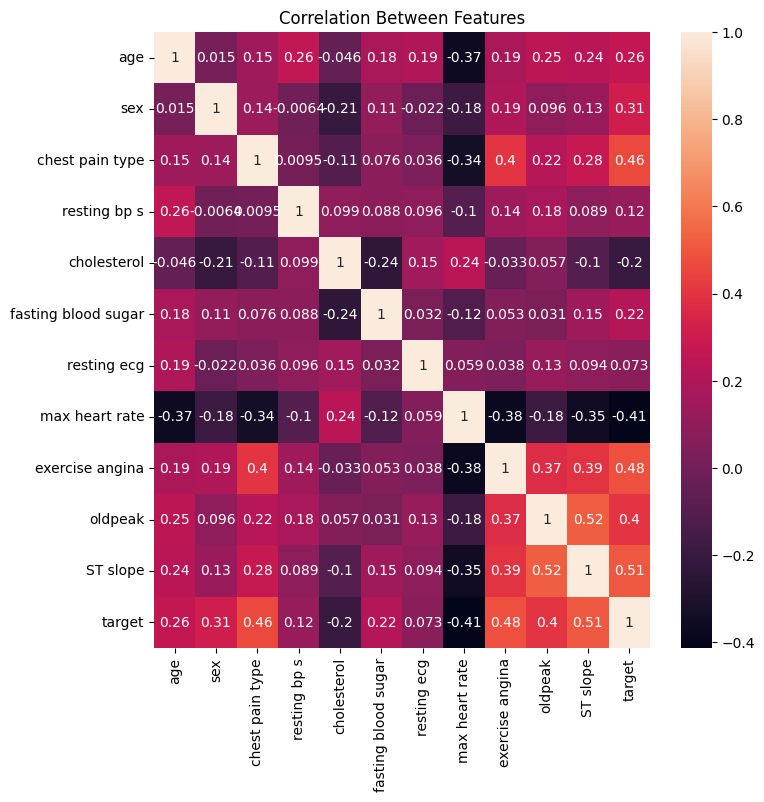

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Between Features')
plt.show()

Oh... And here I thought that the maximum heart rate of a patient has a high correlation with whether someone has a heart disease or not. Well, this is an interesting find. Maybe it's due to the fact that the average age of patients with heart disease is higher than the healthy, that their maximum heart rate decreases?

In [ ]:
df[['age', 'max heart rate','target']].corr()

,age,max heart rate,target
age,1.000000,-0.368676,0.262029
max heart rate,-0.368676,1.000000,-0.413278
target,0.262029,-0.413278,1.000000


Yet again, the correlation of age and max heart rate is negative. In fact, max heart rate has negative correlation with almost all the features. So... they move in opposite directions... When your maximum heart decreases, which is common due to aging, your cholesterol levels increase, for example. That makes sense.

**[ 3 supervised machine learning models to use ]**
- KNN
- Naive Bayes
- Decision Tree

In [ ]:
X = df.drop('target', axis=1)
Y = df['target']

continuous_columns = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak'] # replaces columns_with_many_unique_values
categorical_columns = ['sex','chest pain type','fasting blood sugar', 'resting ecg','exercise angina','ST slope'] # excludes target, replaces columns_with_little_unique_values

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size = 0.3,
    random_state = 42,
    stratify=Y
)

scaler = StandardScaler()
X_scaled_train = X_train.copy()
X_scaled_test = X_test.copy()


X_scaled_train[continuous_columns] = scaler.fit_transform(X_train[continuous_columns])
X_scaled_test[continuous_columns] = scaler.transform(X_test[continuous_columns])

**[ 3 Scenario/Patient Data to Use Later ]**

In [ ]:
# age, sex, chest pain type, resting bp s, cholesterol, fasting blood sugar, resting ecg, max heart rate,
# exercise angina, oldpeak, ST slope + target, but we dont need target
# also let's keep our data close to the mean or within Q1-Q3, or i can just put random numbers

scenarioOne = [[
    57, # 57 yrs old
    0, # Female
    2, # Non-anginal pain
    130, # 130 resting blood pressure
    250, # 250mg/dL cholesterol level
    0, # Low fasting blood sugar (<= 120mg/dL)
    1, # Wave abnormality
    150, # 150bpm max heart rate
    0, # No exercise induced angina
    1, #ST depression induced by exercise relative to rest, whatever that means
    3, # Downsloping
]]

scenarioTwo = [[
    49,
    1,
    3,
    150,
    290,
    1,
    2,
    170,
    1,
    1.5,
    2
]]

scenarioThree = [[
    72,
    1,
    1,
    130,
    300,
    1,
    2,
    140,
    1,
    1,
    1
]]

scenarios = [scenarioOne, scenarioTwo, scenarioThree]



---

# **KNN**

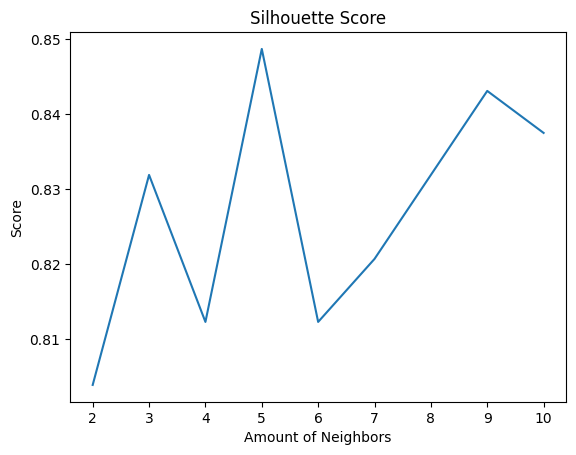

In [ ]:
# I need to find the best amount of nearest neighbors first (using the accuracy score)

knnScores = []
for i in range(2,11):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(X_scaled_train, Y_train)
  Y_pred = knn.predict(X_scaled_test)
  accuracy = accuracy_score(Y_test, Y_pred)
  knnScores.append(accuracy)

plt.plot(range(2,11),knnScores)
plt.title("Silhouette Score")
plt.xlabel("Amount of Neighbors")
plt.ylabel("Score")
plt.show()

Training Accuracy :  88.23529411764706 %
Accuracy :  84.87394957983193 %
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       168
           1       0.84      0.88      0.86       189

    accuracy                           0.85       357
   macro avg       0.85      0.85      0.85       357
weighted avg       0.85      0.85      0.85       357



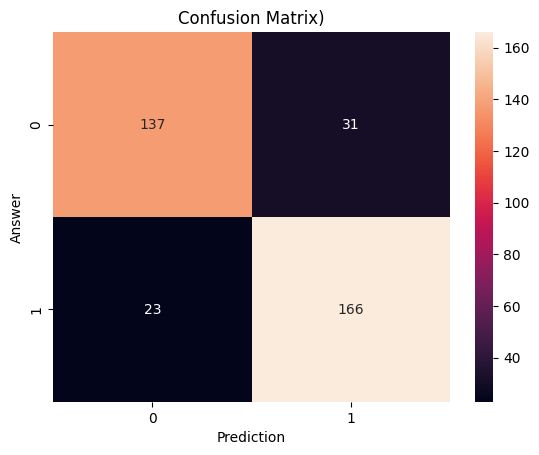

In [ ]:
# Yeah, the best amount of neighbors is 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled_train, Y_train)
Y_pred = knn.predict(X_scaled_test)
accuracy = accuracy_score(Y_test, Y_pred)

training_accuracy = knn.score(X_scaled_train, Y_train)
print("Training Accuracy : ", training_accuracy*100, "%")
print("Accuracy : ", accuracy*100, "%")
print("=========================================================")
print(classification_report(Y_test, Y_pred))
print("=========================================================")
confusionMatrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(confusionMatrix, annot=True, fmt='d')
plt.title("Confusion Matrix)")
plt.xlabel("Prediction")
plt.ylabel("Answer")
plt.show()

---

# Naive Bayes

Training Accuracy :  84.27370948379351 %
Accuracy :  84.03361344537815 %
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       168
           1       0.87      0.82      0.84       189

    accuracy                           0.84       357
   macro avg       0.84      0.84      0.84       357
weighted avg       0.84      0.84      0.84       357



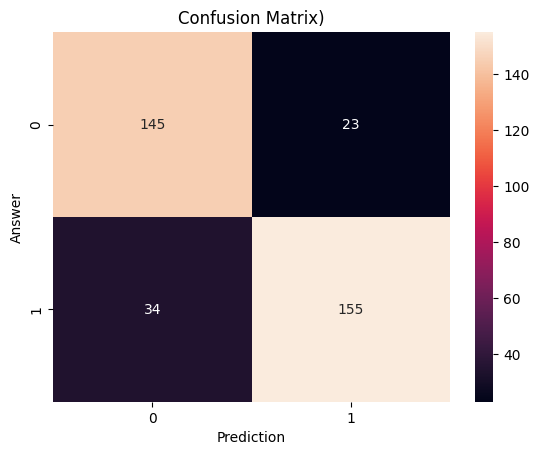

In [ ]:
nb = GaussianNB()
nb.fit(X_scaled_train, Y_train)
Y_pred = nb.predict(X_scaled_test)
accuracy = accuracy_score(Y_test, Y_pred)

training_accuracy = nb.score(X_scaled_train, Y_train)
print("Training Accuracy : ", training_accuracy*100, "%")
print("Accuracy : ", accuracy*100, "%")
print("=========================================================")
print(classification_report(Y_test, Y_pred))
print("=========================================================")
confusionMatrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(confusionMatrix, annot=True, fmt='d')
plt.title("Confusion Matrix)")
plt.xlabel("Prediction")
plt.ylabel("Answer")
plt.show()

---

# Decision Tree

Initially did not give max_depth and this is what we got.

Training Accuracy :  100.0 %

Testing Accuracy :  85.15406162464986 %

=========================================================

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       168
           1       0.88      0.83      0.86       189

    accuracy                           0.85       357
    macro avg       0.85      0.85      0.85       357
    weighted avg       0.85      0.85      0.85       357


=========================================================

Decision Tree overfitting, need to limit depth.

In [ ]:
dt_train_acc_score = []
dt_test_acc_score = []

for i in range(1,11):
  dt = DecisionTreeClassifier(random_state=42, max_depth=i)
  dt.fit(X_scaled_train, Y_train)

  train_pred = dt.predict(X_scaled_train)
  test_pred = dt.predict(X_scaled_test)

  train_accuracy = accuracy_score(Y_train, train_pred)
  test_accuracy = accuracy_score(Y_test, test_pred)

  dt_train_acc_score.append(train_accuracy)
  dt_test_acc_score.append(test_accuracy)
  print("Depth : ", i, " | Training accuracy : ", train_accuracy*100, "% | Testing accuracy : ", test_accuracy*100)

Depth :  1  | Training accuracy :  77.19087635054022 % | Testing accuracy :  81.5126050420168
Depth :  2  | Training accuracy :  77.19087635054022 % | Testing accuracy :  81.5126050420168
Depth :  3  | Training accuracy :  83.55342136854742 % | Testing accuracy :  84.87394957983193
Depth :  4  | Training accuracy :  84.03361344537815 % | Testing accuracy :  84.87394957983193
Depth :  5  | Training accuracy :  88.11524609843937 % | Testing accuracy :  82.6330532212885
Depth :  6  | Training accuracy :  90.39615846338536 % | Testing accuracy :  82.6330532212885
Depth :  7  | Training accuracy :  94.11764705882352 % | Testing accuracy :  84.03361344537815
Depth :  8  | Training accuracy :  95.43817527010803 % | Testing accuracy :  82.35294117647058
Depth :  9  | Training accuracy :  97.71908763505402 % | Testing accuracy :  84.31372549019608
Depth :  10  | Training accuracy :  98.5594237695078 % | Testing accuracy :  83.75350140056022


The 3 highest test accuracies are when depth is equal to 3&4, 9, and 7. I'm probably inclined to taking depth 3 or 4. I probably should take the training accuracy closest to the testing accuracy, so that's depth 4.

Training Accuracy :  84.03361344537815 %
Testing Accuracy :  84.87394957983193 %
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       168
           1       0.83      0.90      0.86       189

    accuracy                           0.85       357
   macro avg       0.85      0.85      0.85       357
weighted avg       0.85      0.85      0.85       357



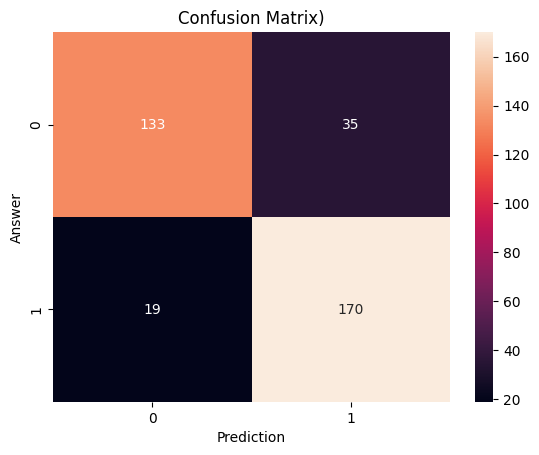

In [ ]:
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_scaled_train, Y_train)
Y_pred = dt.predict(X_scaled_test)
accuracy = accuracy_score(Y_test, Y_pred)

training_accuracy = dt.score(X_scaled_train, Y_train)
print("Training Accuracy : ", training_accuracy*100, "%") #100%, we should uh limit the depth then
print("Testing Accuracy : ", accuracy*100, "%")
print("=========================================================")
print(classification_report(Y_test, Y_pred))
print("=========================================================")
confusionMatrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(confusionMatrix, annot=True, fmt='d')
plt.title("Confusion Matrix)")
plt.xlabel("Prediction")
plt.ylabel("Answer")
plt.show()

---

# Running the Three Scenarios on Three Models

In [ ]:
print("PREDICTED TARGET (NORMAL/HEART DISEASE)")
print("==============================================================")
i = 0
for scenario in scenarios:
  scenario_df = pd.DataFrame(scenario, columns=X.columns)
  scenario_scaled = scenario_df.copy()
  scenario_scaled[continuous_columns] = scaler.transform(scenario_df[continuous_columns])

  i = i + 1
  print("Scenario ", i)
  print(scenario)
  print("KNN : ", target_mapping[knn.predict(scenario_scaled)[0]])
  print("Naive Bayes : ", target_mapping[nb.predict(scenario_scaled)[0]])
  print("Decision Tree : ", target_mapping[dt.predict(scenario_scaled)[0]])
  print("==============================================================")

PREDICTED TARGET (NORMAL/HEART DISEASE)
Scenario  1
[[57, 0, 2, 130, 250, 0, 1, 150, 0, 1, 3]]
KNN :  Normal
Naive Bayes :  Normal
Decision Tree :  Normal
Scenario  2
[[49, 1, 3, 150, 290, 1, 2, 170, 1, 1.5, 2]]
KNN :  Normal
Naive Bayes :  Heart Disease
Decision Tree :  Heart Disease
Scenario  3
[[72, 1, 1, 130, 300, 1, 2, 140, 1, 1, 1]]
KNN :  Normal
Naive Bayes :  Heart Disease
Decision Tree :  Normal


In [ ]:
print("PROBABILITY OF NORMAL VS HEART DISEASE")
print("[[0.8 0.2]] means 80% chance it's Normal and 20% chance it's Heart Disease")
print("==============================================================")
i = 0
for scenario in scenarios:
  scenario_df = pd.DataFrame(scenario, columns=X.columns)
  scenario_scaled = scenario_df.copy()
  scenario_scaled[continuous_columns] = scaler.transform(scenario_df[continuous_columns])

  i = i + 1
  print("Scenario ", i)
  print("Patient Data : ", scenario)
  print("KNN : ", knn.predict_proba(scenario_scaled))
  print("Naive Bayes : ", nb.predict_proba(scenario_scaled))
  print("Decision Tree : ", dt.predict_proba(scenario_scaled))
  print("==============================================================")

PROBABILITY OF NORMAL VS HEART DISEASE
[[0.8 0.2]] means 80% chance it's Normal and 20% chance it's Heart Disease
Scenario  1
Patient Data :  [[57, 0, 2, 130, 250, 0, 1, 150, 0, 1, 3]]
KNN :  [[0.8 0.2]]
Naive Bayes :  [[0.97695783 0.02304217]]
Decision Tree :  [[1. 0.]]
Scenario  2
Patient Data :  [[49, 1, 3, 150, 290, 1, 2, 170, 1, 1.5, 2]]
KNN :  [[0.6 0.4]]
Naive Bayes :  [[0.00600442 0.99399558]]
Decision Tree :  [[0. 1.]]
Scenario  3
Patient Data :  [[72, 1, 1, 130, 300, 1, 2, 140, 1, 1, 1]]
KNN :  [[0.6 0.4]]
Naive Bayes :  [[0.33853162 0.66146838]]
Decision Tree :  [[1. 0.]]
